<img src="../../TPs_Semanal/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# Trabajo Practico de Laboratorio N°1
#### Autor:Nicolas Trombetta
#### Profesor: Mariano Llamedo Soria

El Trabajo tiene como objetivo el diseño e implementacion de dos filtros digitales que cumplan con las siguentes plantillas

| *Filtro * | *Función de Aproximación* | $f_p$ | $f_s$ | $\alpha_{max}$ | $\alpha_{min}$ |
| :--- | :--- | :--- | :--- | :--- | :--- |
| A | Chebyshev | 100 Hz | 300 Hz | 1 dB | 60 dB |

<br>

| *Filtro* | *Tipo* | $f_{notch}$ | **BW @ 3dB** |
| :--- | :--- | :--- | :--- |
| B | Notch | 50 Hz | 1 Hz |

Para el diseño de los mismos utiizamos  [irrdesign](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html#scipy.signal.iirdesign) de scipy  

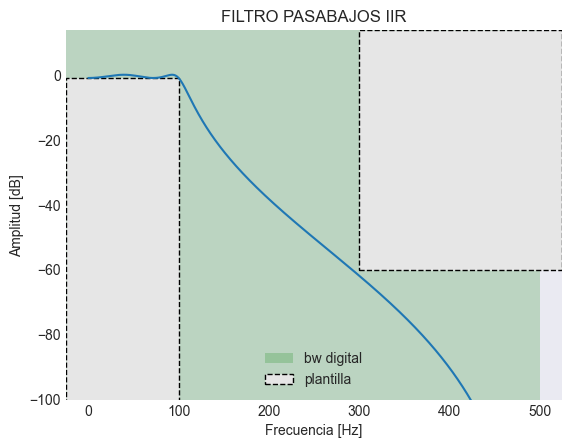

<IPython.core.display.Latex object>

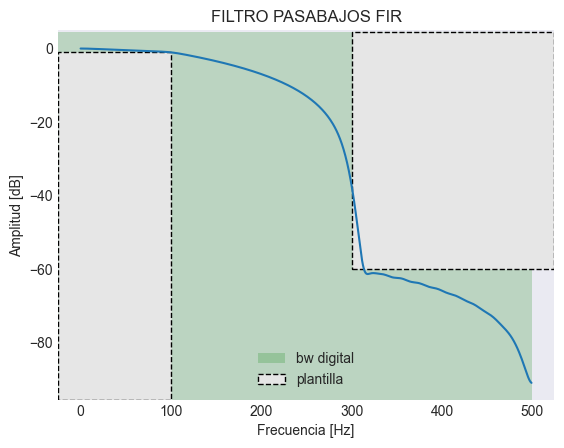

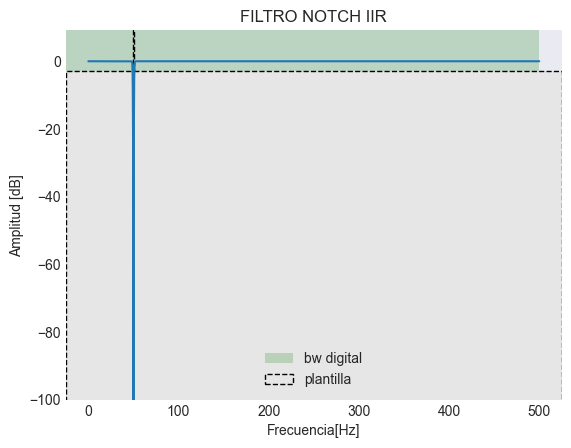

<IPython.core.display.Latex object>

In [51]:
import numpy as np
import scipy.signal as sp
from matplotlib import pyplot as plt
from pytc2.sistemas_lineales import plot_plantilla

from IPython.display import Latex, display

def sos_to_latex(sos, var="z"):
    latex_str = f"$$H({var}) = "
    sections = []

    for row in sos:
        b0, b1, b2, a0, a1, a2 = row

        # Construcción del numerador
        num = f"{b0:.4f}"
        if b1 != 0:
            num += f" {'+' if b1 > 0 else '-'} {abs(b1):.4f}{var}^{{-1}}"
        if b2 != 0:
            num += f" {'+' if b2 > 0 else '-'} {abs(b2):.4f}{var}^{{-2}}"

        # Construcción del denominador
        den = f"{a0:.4f}"
        if a1 != 0:
            den += f" {'+' if a1 > 0 else '-'} {abs(a1):.4f}{var}^{{-1}}"
        if a2 != 0:
            den += f" {'+' if a2 > 0 else '-'} {abs(a2):.4f}{var}^{{-2}}"

        sections.append(rf"\frac{{{num}}}{{{den}}}")

    latex_str += r" \cdot ".join(sections) + "$$"
    display(Latex(latex_str))

################## Filtro A #######################
## Funcion de aprox: Chebyshev
## fp: 100Hz
## fs: 300Hz
## alfa_max: 1db
## alfa_min: 60db

fp = 100#Hz
fstop = 300#Hz
alfa_max = 1#db
alfa_min = 60#db
fs=1000#Hz

###IIR
system_a = signal.iirdesign(fp, fstop, alfa_max, alfa_min,ftype='cheby1',output='sos',fs=fs)
w, h = signal.freqz_sos(system_a,worN=1000,fs=fs)

plt.close('all')

plt.figure()

plt.plot(w,20*np.log10(np.abs(h)))


plt.title('FILTRO PASABAJOS IIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(which='both', axis='both')

#plt.gca().set_xlim([0, 1])

plot_plantilla(filter_type = 'lowpass' , fpass = fp, ripple = alfa_max , fstop = fstop, attenuation = alfa_min, fs = fs)
sos_to_latex(system_a, var="z")

###FIR
N = 101

frecs = [0, fp, fstop, fs/2]
gains = [0, -alfa_max, -alfa_min, -np.inf]
gains = 10**(np.array(gains)/20)

bfir = sp.firwin2(N, frecs, gains , window='hamming',fs=fs)
wfir, hfir = sp.freqz(bfir, fs=fs)
magfir = 20 * np.log10(np.abs(hfir))

plt.figure()
plt.plot(wfir,magfir)

plt.title('FILTRO PASABAJOS FIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(which='both', axis='both')

plot_plantilla(filter_type = 'lowpass' , fpass = fp, ripple = alfa_max , fstop = fstop, attenuation = alfa_min, fs = fs)

################## Filtro B #######################

fnotch=50#HZ
fpass = [fnotch-0.05,fnotch+0.05] #Hz
BW=2#HZ
fstop = [fnotch-BW/2,fnotch+BW/2] #Hz
alfa_max = 3#db
alfa_min = 60#db
fs=1000#Hz


system_b = signal.iirdesign(fstop,fpass, alfa_max, alfa_min,ftype='butter',output='sos',fs=fs)
w, h = signal.freqz_sos(system_b,worN=10000,fs=fs)

plt.figure()

plt.plot(w,20*np.log10(np.abs(h)))


plt.title('FILTRO NOTCH IIR')
plt.xlabel('Frecuencia[Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(which='both', axis='both')

#plt.gca().set_xlim([0, 1])

plot_plantilla(filter_type = 'bandstop' , fpass = fpass, ripple = alfa_max , fstop = fstop, attenuation = alfa_min, fs = fs)

# Llamada para imprimir tu filtro en Jupyter
sos_to_latex(system_b, var="z")

**Observacion**: Es claro que el filtro pasabajos FIR no satisface completamente los requerimientos de la plantilla, sin embargo durante el laboratorio no lo notamos y lo implementamos de esa manera.

## Implementacion
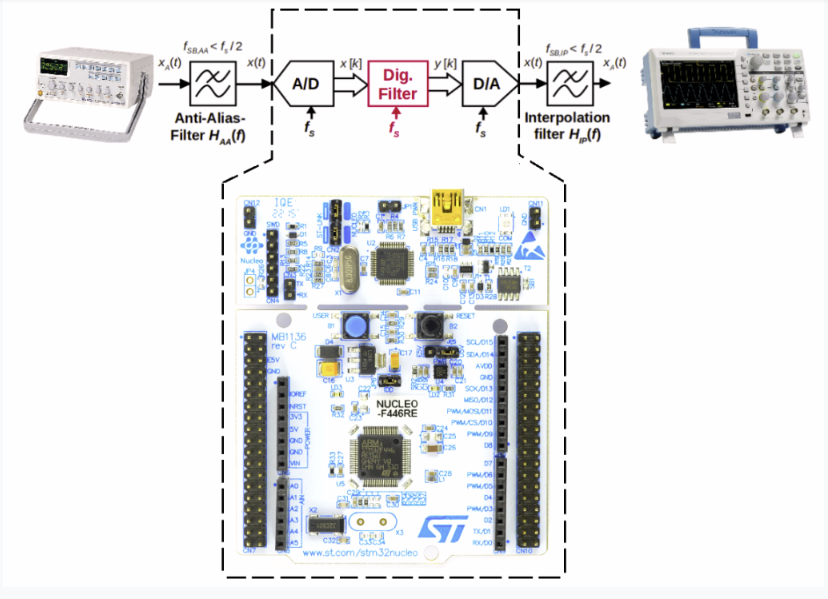

Para poder cumplir con el criterio de Nyquist se coloca un filtro Antialias que limita la frecuencia de la señal de entrada. Para ello implementamos un filtro pasabajos RC con $R=1.2k\Omega$ y $C=470nF$, lo que fija una frecuencia de corte $f_c \approx 282\text{ Hz}$.
Ademas se coloco a la salida del MCU un filtro interpolador para filtrar las replicas periodicas de la señal que produce el DAC. Se construyo con las mismas especificaciones que el antialias.

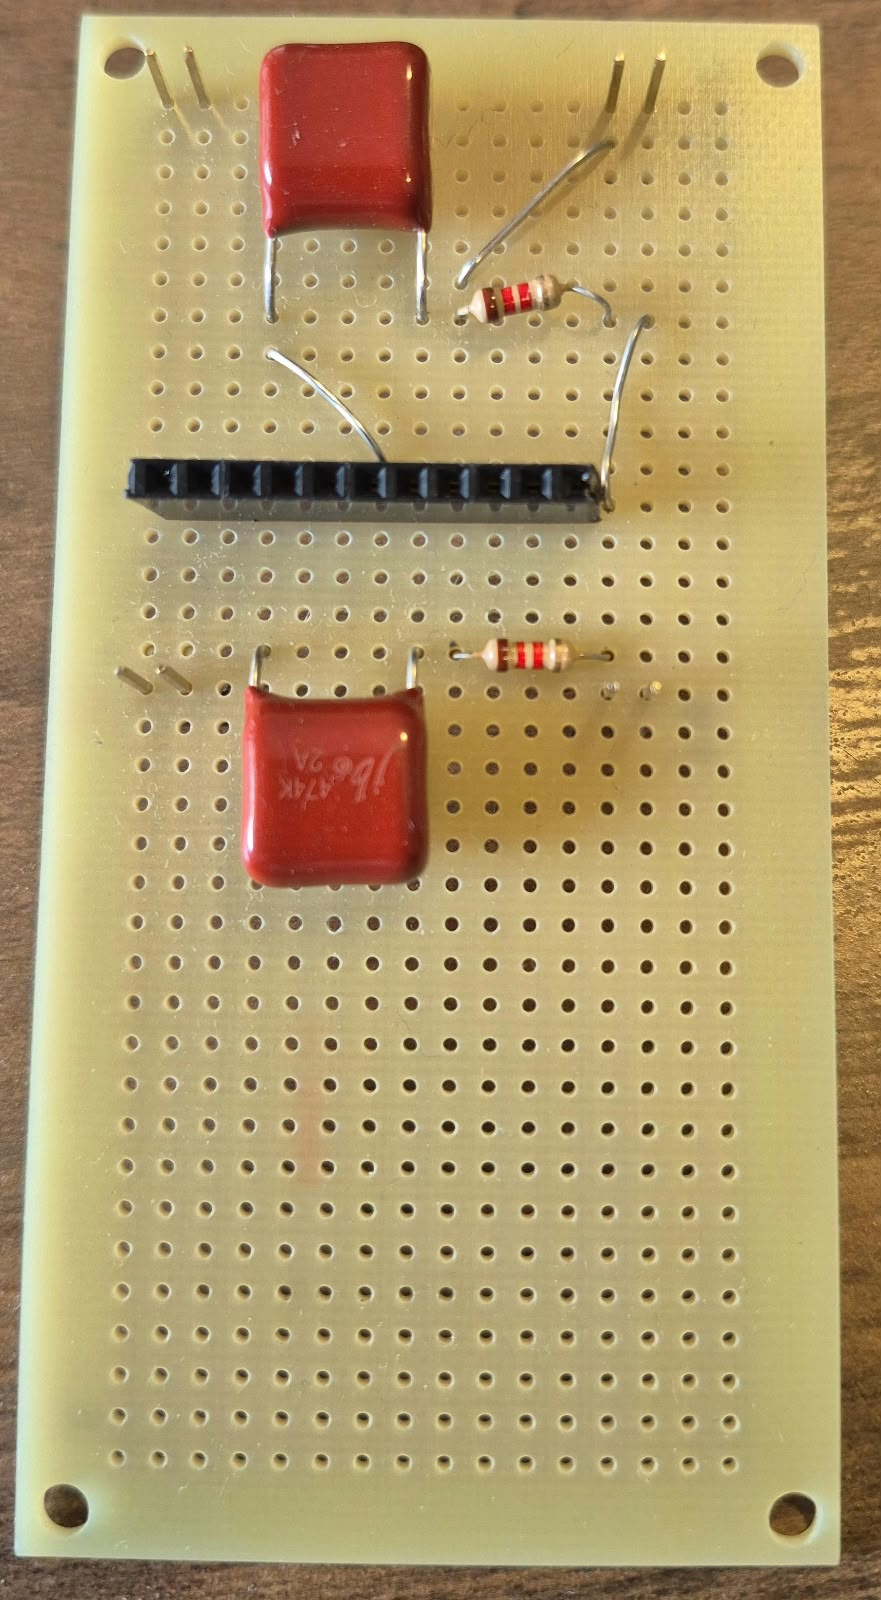

Para implementar el filtro digital utilizamos la placa de desarrollo **NUCLEO-F446RE**.
para simplificar la tarea instanciamos funciones de la librería de procesamiento digital[CMSIS-DSP](https://arm-software.github.io/CMSIS_6/latest/General/index.html) de ARM.

## Laboratorio
  Para la medición de la respuesta del filtro se utilizó un osciloscopio de dos canales, conectando el primer canal a la entrada del circuito y el segundo a la salida. Mediante un generador de señales se aplicó una señal senoidal cuya frecuencia se fue variando de manera gradual. Para cada frecuencia se registraron la amplitud de la señal de salida

### Medidas de Laboratorio con osciloscopio

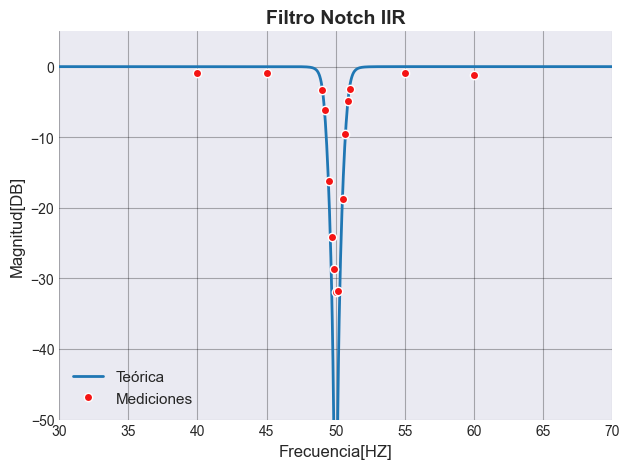

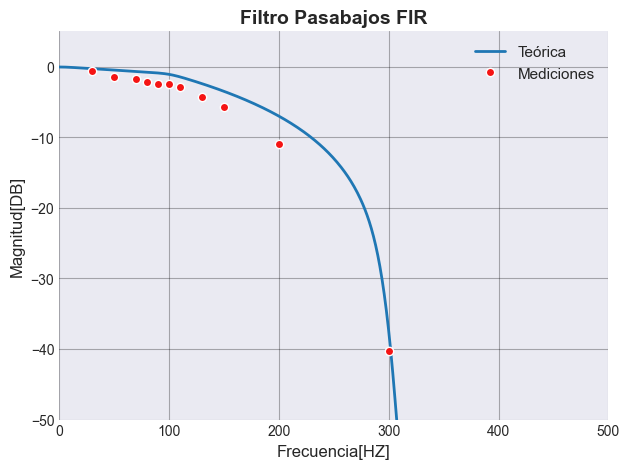

In [46]:
import matplotlib.pyplot as plt
from scipy import signal as sig

plt.style.use('seaborn-v0_8-darkgrid')


##########################FILTRO NOTCH IIR########################
f = np.array([40,45,49,49.2,49.5,49.7,49.9,50,50.2,50.5,50.7,50.9,51,55,60])
V_in = np.array([3.35,3.27,3.27,3.16,3.35,3.24,3.24,3.16,3.11,3.11,3.11,3.03,3.11,3.27,3.31])
V_out = np.array([3.03,2.96,2.24,1.55,520e-3,200e-3,120e-3,80e-3,80e-3,360e-3,1.03,1.72,2.16,2.96,2.88])

T = 20 * np.log10(V_out / V_in)

fig, ax1 = plt.subplots()

ax1.plot(w, 20*np.log10(np.abs(h)), label='Teórica', linewidth=2)
ax1.plot(f, T, 'o', label='Mediciones', markersize=6, color='#f51414', markeredgecolor='white', markeredgewidth=1)
ax1.set_xlabel('Frecuencia[HZ]', fontsize=12)
ax1.set_ylabel('Magnitud[DB]', fontsize=12)
ax1.set_title('Filtro Notch IIR', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, which='both',color='black', alpha=0.3)
ax1.tick_params(labelsize=10)

ax1.set_xlim([30, 70])

ax1.set_ylim([-50, 5])

plt.tight_layout()
plt.show()

##########################FILTRO PASABAJOS FIR##############################
f = np.array([30,50,70,80,90,100,110,130,150,200,300])
V_in = np.array([2.11,2.20,2.15,2.16,2.16,2.11,2.1,2.07,2.07,2.05,2.05])
V_out = np.array([1.96,1.87,1.75,1.67,1.63,1.60,1.51,1.27,1.08,0.576,0.02])

T = 20 * np.log10(V_out / V_in)

fig, ax1 = plt.subplots()

ax1.plot(wfir,magfir, label='Teórica', linewidth=2)
ax1.plot(f, T, 'o', label='Mediciones', markersize=6, color='#f51414', markeredgecolor='white', markeredgewidth=1)
ax1.set_xlabel('Frecuencia[HZ]', fontsize=12)
ax1.set_ylabel('Magnitud[DB]', fontsize=12)
ax1.set_title('Filtro Pasabajos FIR', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, which='both',color='black', alpha=0.3)
ax1.tick_params(labelsize=10)

ax1.set_xlim([0, 500])

ax1.set_ylim([-50, 5])

plt.tight_layout()
plt.show()


### Conclusion
Se logró el diseño e implementación de los filtros digitales solicitados utilizando las herramientas de cálculo y síntesis de scipy.signal.
Como mejora, se podria corregir el filtro pasabajos FIR, haciendo mas restrictivo la frecuencia de stop.